### library

In [1]:
!cp -r '/kaggle/input/nips-adc-package/package' '/kaggle/working/'
!pip install --no-index --find-links=/kaggle/working/package scipy==1.16.0

Looking in links: /kaggle/working/package
Processing ./package/scipy-1.16.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.16.0 which is incompatible.
ydata-profiling 4.16.1 requires scipy<1.16,>=1.4.1, but you have scipy 1.16.0 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.2.2 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, bu

In [2]:
import pandas as pd

import numpy as np
from numpy.polynomial.polynomial import Polynomial

import glob

import os

from tqdm import tqdm

import matplotlib.pyplot as plt

try:
    from astropy.stats import sigma_clip
except:
    pass

import itertools

from scipy.optimize import minimize, curve_fit, least_squares
from scipy.sparse import lil_matrix
from scipy.ndimage import gaussian_filter1d

import torch

if torch.cuda.is_available():
    import cupy as cp

from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import r2_score, accuracy_score

from multiprocessing import Pool

### config

In [3]:
class CustomConfig:
    root = '/kaggle/input/ariel-data-challenge-2025/'

    seed = 42
    
    n_fold = 4

    split = 'test'

    crop = 8

    cut_inf = 39
    cut_sup = 321

    binning = {
        'AIRS-CH0' : 30,
        'FGS1' : 30 * 12,
    }

    columns = pd.read_csv(root + 'sample_submission.csv', index_col = 'planet_id').columns

    threshold = 1e-2
    sigma = 4e-4
    fgs_sigma = 8e-4

    if '2024' in root:
        train = pd.read_csv(root + 'train_labels.csv')
    else:
        train = pd.read_csv(root + 'train.csv')

    naive_mean = train.values[:, 1:].mean()
    naive_sigma = train.values[:, 1:].std()

    fgs_weight = (0.4 / 1.95) * 282

    instruments = [
        'FGS1',
        'AIRS-CH0',
    ]

### utils

In [4]:
# ref.: https://www.kaggle.com/code/gordonyip/calibrating-and-binning-ariel-data/notebook

def ADC_convert(signal, gain=0.4369, offset=-1000):
    """The Analog-to-Digital Conversion (adc) is performed by the detector to convert
    the pixel voltage into an integer number. Since we are using the same conversion number 
    this year, we have simply hard-coded it inside. """
    signal = signal.astype(np.float64)
    signal /= gain
    signal += offset
    return signal

def mask_hot_dead(signal, dead, dark):
    hot = sigma_clip(
        dark, sigma=5, maxiters=5
    ).mask
    hot = np.tile(hot, (signal.shape[0], 1, 1))
    dead = np.tile(dead, (signal.shape[0], 1, 1))
    signal = np.ma.masked_where(dead, signal)
    signal = np.ma.masked_where(hot, signal)
    return signal

def apply_linear_corr(linear_corr,clean_signal):
    linear_corr = np.flip(linear_corr, axis=0)
    for x, y in itertools.product(
                range(clean_signal.shape[1]), range(clean_signal.shape[2])
            ):
        poli = np.poly1d(linear_corr[:, x, y])
        clean_signal[:, x, y] = poli(clean_signal[:, x, y])
    return clean_signal

def clean_dark(signal, dead, dark, dt):

    dark = np.ma.masked_where(dead, dark)
    dark = np.tile(dark, (signal.shape[0], 1, 1))

    signal -= dark* dt[:, np.newaxis, np.newaxis]
    return signal

def get_cds(signal):
    cds = signal[:,1::2,:,:] - signal[:,::2,:,:]
    return cds

def bin_obs(cds_signal,binning):
    cds_transposed = cds_signal.transpose(0,1,3,2)
    cds_binned = np.zeros((cds_transposed.shape[0], cds_transposed.shape[1]//binning, cds_transposed.shape[2], cds_transposed.shape[3]))
    for i in range(cds_transposed.shape[1]//binning):
        cds_binned[:,i,:,:] = np.sum(cds_transposed[:,i*binning:(i+1)*binning,:,:], axis=1)
    return cds_binned

def correct_flat_field(flat,dead, signal):
    flat = flat.transpose(1, 0)
    dead = dead.transpose(1, 0)
    flat = np.ma.masked_where(dead, flat)
    flat = np.tile(flat, (signal.shape[0], 1, 1))
    signal = signal / flat
    return signal

In [5]:
def apply_linear_corr_gpu(linear_corr, signal):
    '''
    horner’s method in-place : y = (((((a5 * x + a4) * x + a3) * x + a2) * x + a1) * x + a0)
    '''
    
    linear_corr = cp.asarray(linear_corr)
    signal = cp.asarray(signal)    
    out = cp.full_like(signal, linear_corr[-1])

    for i in range(linear_corr.shape[0] - 2, -1, -1):
        cp.multiply(out, signal, out = out)    
        cp.add(out, linear_corr[i], out = out)
    
    out = cp.asnumpy(out)
    return out

if __name__ == '__main__':
    '''
    linear_corr = np.random.randn(6, 32, 32)
    signal = np.random.randn(135000, 32, 32)

    x1 = apply_linear_corr(linear_corr.copy(), signal.copy())
    x2 = apply_linear_corr_gpu(linear_corr.copy(), signal.copy())

    print(np.allclose(x1, x2))
    '''

In [6]:
def get_solution(args, train, planet_ids):
    rows = []
    for planet_id in planet_ids:
        true = train[train.planet_id == planet_id].values[0, 1:]
        
        row = {'planet_id' : planet_id}
        for i, column in enumerate(args.columns[:283]):
            row[column] = true[i]

        rows.append(row)

    solution = pd.DataFrame(rows)
    return solution

def get_score(args, submission, solution = None, print_score = True):            
    planet_ids = [int(_) for _ in submission.planet_id.values]

    if '2024' in args.root:
        train = pd.read_csv('/kaggle/input/ariel-data-challenge-2024/train_labels.csv')
    else:
        train = pd.read_csv('/kaggle/input/ariel-data-challenge-2025/train.csv')

    if solution is None:
        solution = get_solution(args, train, planet_ids)

    scores, scores2, score = score_function(
        solution = solution.copy(),
        submission = submission.copy(),
        row_id_column_name = 'planet_id',
        naive_mean = args.naive_mean,
        naive_sigma = args.naive_sigma,
        fgs_weight = args.fgs_weight,
        print_score = print_score,
    )
    return scores, scores2, score

In [7]:
def remove_outlier(data, window = 100, threshold = 5.0):
    df = pd.DataFrame(data)
    
    mean = df.rolling(window = window, center = True, min_periods = 1).mean()
    std = df.rolling(window = window, center = True, min_periods = 1).std()
    
    mask = (df - mean).abs() > (threshold * std)
    
    df[mask] = mean[mask]
    data = df.to_numpy()
    return data

def bin_function(data, binning):
    _data = np.zeros((data.shape[0]//binning, data.shape[1]))

    for i in range(data.shape[0]//binning):
        _data[i, :] = np.mean(data[i * binning:(i + 1) * binning, :], axis = 0)
        
    return _data

def pca_function(x, n_components):
    pca = PCA()
    
    _x = pca.fit_transform(x)
    _x[:, n_components:] = 0
    x = pca.inverse_transform(_x)[:, :]
    
    return x

### metric

In [8]:
# ref.: https://www.kaggle.com/code/metric/ariel-gaussian-log-likelihood

import numpy as np
import pandas as pd
import pandas.api.types
import scipy.stats


class ParticipantVisibleError(Exception):
    pass


def score_function(
    solution: pd.DataFrame,
    submission: pd.DataFrame,
    row_id_column_name: str,
    naive_mean: float,
    naive_sigma: float,
    fsg_sigma_true: float = 1e-6,
    airs_sigma_true: float = 1e-5,
    fgs_weight: float = 1,
    print_score : bool = True,
) -> float:
    """
    This is a Gaussian Log Likelihood based metric. For a submission, which contains the predicted mean (x_hat) and variance (x_hat_std),
    we calculate the Gaussian Log-likelihood (GLL) value to the provided ground truth (x). We treat each pair of x_hat,
    x_hat_std as a 1D gaussian, meaning there will be 283 1D gaussian distributions, hence 283 values for each test spectrum,
    the GLL value for one spectrum is the sum of all of them.

    Inputs:
        - solution: Ground Truth spectra (from test set)
            - shape: (nsamples, n_wavelengths)
        - submission: Predicted spectra and errors (from participants)
            - shape: (nsamples, n_wavelengths*2)
        naive_mean: (float) mean from the train set.
        naive_sigma: (float) standard deviation from the train set.
        fsg_sigma_true: (float) standard deviation from the FSG1 instrument for the test set.
        airs_sigma_true: (float) standard deviation from the AIRS instrument for the test set.
        fgs_weight: (float) relative weight of the fgs channel
    """

    del solution[row_id_column_name]
    del submission[row_id_column_name]

    if submission.min().min() < 0:
        raise ParticipantVisibleError('Negative values in the submission')
    for col in submission.columns:
        if not pandas.api.types.is_numeric_dtype(submission[col]):
            raise ParticipantVisibleError(f'Submission column {col} must be a number')

    n_wavelengths = len(solution.columns)
    if len(submission.columns) != n_wavelengths * 2:
        raise ParticipantVisibleError('Wrong number of columns in the submission')

    y_pred = submission.iloc[:, :n_wavelengths].values
    # Set a non-zero minimum sigma pred to prevent division by zero errors.
    sigma_pred = np.clip(submission.iloc[:, n_wavelengths:].values, a_min=10**-15, a_max=None)
    sigma_true = np.append(
        np.array(
            [
                fsg_sigma_true,
            ]
        ),
        np.ones(n_wavelengths - 1) * airs_sigma_true,
    )
    y_true = solution.values

    GLL_pred = scipy.stats.norm.logpdf(y_true, loc=y_pred, scale=sigma_pred)
    GLL_true = scipy.stats.norm.logpdf(y_true, loc=y_true, scale=sigma_true * np.ones_like(y_true))
    GLL_mean = scipy.stats.norm.logpdf(y_true, loc=naive_mean * np.ones_like(y_true), scale=naive_sigma * np.ones_like(y_true))

    # normalise the score, right now it becomes a matrix instead of a scalar.
    ind_scores = (GLL_pred - GLL_mean) / (GLL_true - GLL_mean)
    if print_score:
        print(ind_scores.mean(1))

    weights = np.append(np.array([fgs_weight]), np.ones(len(solution.columns) - 1))
    weights = weights * np.ones_like(ind_scores)
    submit_score = np.average(ind_scores, weights=weights)

    scores = ((ind_scores * weights).sum(1) / weights.sum(1))
    if print_score:
        print(scores)
    return scores, ind_scores.mean(1), float(submit_score)#float(np.clip(submit_score, 0.0, 1.0))

### preprocess

index :  0 , planet_id :  1103775
data :  (187, 283)


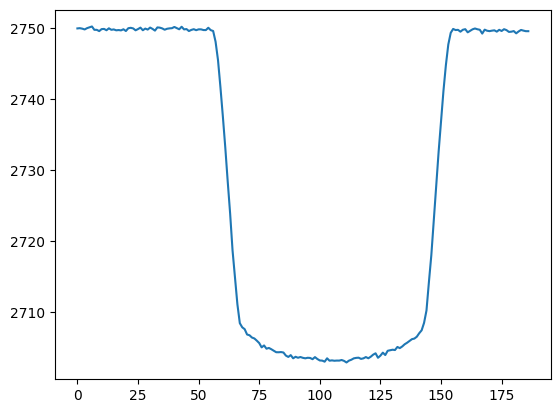

In [9]:
def read_data(args, planet_id, instrument, observation_count = 0):
    if '2024' in args.root:
        signal = pd.read_parquet(args.root + f'{args.split}/{planet_id}/{instrument}_signal.parquet').values.astype(np.float64)
        
        flat = pd.read_parquet(args.root + f'{args.split}/{planet_id}/{instrument}_calibration/flat.parquet').values.astype(np.float64)    
        dark = pd.read_parquet(args.root + f'{args.split}/{planet_id}/{instrument}_calibration/dark.parquet').values.astype(np.float64)    
        dead = pd.read_parquet(args.root + f'{args.split}/{planet_id}/{instrument}_calibration/dead.parquet').values.astype(np.float64)
        linear_corr = pd.read_parquet(args.root + f'{args.split}/{planet_id}/{instrument}_calibration/linear_corr.parquet').values.astype(np.float64)
    else:
        signal = pd.read_parquet(args.root + f'{args.split}/{planet_id}/{instrument}_signal_{observation_count}.parquet').values.astype(np.float64)
        
        flat = pd.read_parquet(args.root + f'{args.split}/{planet_id}/{instrument}_calibration_{observation_count}/flat.parquet').values.astype(np.float64)    
        dark = pd.read_parquet(args.root + f'{args.split}/{planet_id}/{instrument}_calibration_{observation_count}/dark.parquet').values.astype(np.float64)    
        dead = pd.read_parquet(args.root + f'{args.split}/{planet_id}/{instrument}_calibration_{observation_count}/dead.parquet').values.astype(np.float64)
        linear_corr = pd.read_parquet(args.root + f'{args.split}/{planet_id}/{instrument}_calibration_{observation_count}/linear_corr.parquet').values.astype(np.float64)

    if instrument == 'AIRS-CH0':
        signal = signal.reshape(signal.shape[0], 32, 356)[:, args.crop:32-args.crop, args.cut_inf:args.cut_sup]

        dt = axis_info['AIRS-CH0-integration_time'].dropna().values
        dt[1::2] += 0.1
        
        flat = flat.reshape(32, 356)[args.crop:32-args.crop, args.cut_inf:args.cut_sup]    
        dark = dark.reshape(32, 356)[args.crop:32-args.crop, args.cut_inf:args.cut_sup]     
        dead = dead.reshape(32, 356)[args.crop:32-args.crop, args.cut_inf:args.cut_sup]     
        linear_corr = linear_corr.reshape(6, 32, 356)[:, args.crop:32-args.crop, args.cut_inf:args.cut_sup] 
    else:
        signal = signal.reshape(signal.shape[0], 32, 32)[:, args.crop:32-args.crop, args.crop:32-args.crop]

        dt = np.ones(signal.shape[0]) * 0.1
        dt[1::2] += 0.1
        
        flat = flat.reshape(32, 32)[args.crop:32-args.crop, args.crop:32-args.crop]
        dark = dark.reshape(32, 32)[args.crop:32-args.crop, args.crop:32-args.crop]
        dead = dead.reshape(32, 32)[args.crop:32-args.crop, args.crop:32-args.crop]
        linear_corr = linear_corr.reshape(6, 32, 32)[:, args.crop:32-args.crop, args.crop:32-args.crop]
    return signal, dt, flat, dark, dead, linear_corr

def calibrate_data(args, signal, dt, flat, dark, dead, linear_corr, binning):
    signal = ADC_convert(signal)
    
    #signal = mask_hot_dead(signal, dead, dark)

    if torch.cuda.is_available():
        signal = apply_linear_corr_gpu(linear_corr, signal)
    else:
        signal = apply_linear_corr(linear_corr, signal)
    
    signal = clean_dark(signal, dead, dark, dt)

    signal = signal[None]

    signal = get_cds(signal)
    
    signal = signal.transpose(0, 1, 3, 2)

    signal = signal[0]

    signal = correct_flat_field(flat, dead, signal)
    signal = signal.filled(fill_value = np.nan)

    signal = signal[:, ::-1]
    return signal

def preprocess_function(args, planet_id, observation_count = 0):
    data = []
    for instrument in args.instruments:
        _data, dt, flat, dark, dead, linear_corr = read_data(args, planet_id, instrument, observation_count)
        _data = calibrate_data(args, _data, dt, flat, dark, dead, linear_corr, args.binning[instrument])           
        _data = np.nanmean(_data, axis = 2)
    
        _data = remove_outlier(_data)
        if args.binning[instrument] != None:
            _data = bin_function(_data, args.binning[instrument])

        if instrument == 'FGS1':
            _data = np.mean(_data, axis = 1, keepdims = True)

        data.append(_data)

    data = np.concatenate(data, axis = 1)
    return data

if __name__ == '__main__':
    args = CustomConfig()

    args.root = '/kaggle/input/ariel-data-challenge-2025/'
 
    axis_info = pd.read_parquet(args.root + 'axis_info.parquet')
    
    planet_ids = glob.glob(args.root + f'{args.split}/*')
    planet_ids = sorted([_.split('/')[-1] for _ in planet_ids])

    #'''
    if args.split == 'train':
        cv = pd.read_csv('/kaggle/input/nips-adc-data/cv6.csv')
        planet_ids = cv[(cv.weighted_score <= 0.44) & (cv.success == True)]['planet_id'].tolist()
        print('n_planet : ', len(planet_ids))
    #'''

    index = np.random.randint(0, len(planet_ids))
    planet_id = planet_ids[index]
    print('index : ', index, ', planet_id : ', planet_id)
    
    data = preprocess_function(args, planet_id)
    print('data : ', data.shape)

    plt.plot(data.mean(1))
    plt.show()

### stage1

params :  [0.3073, 0.3585, 0.7713, 0.8223, 1.9348, 4.8497, -0.0381, -0.0116, -0.0869, 0.0881]
success :  True


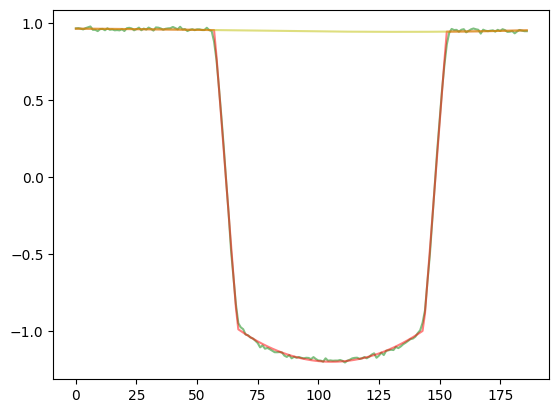

In [10]:
def model1(time, T1, T2, T3, T4, depth, dark, *coeffs):
    def get_transit(time, T1, T2, T3, T4, depth, dark):
        transit = np.ones_like(time)

        ingress_mask = (time >= T1) & (time <= T2)
        egress_mask = (time >= T3) & (time <= T4)
        transit_mask = (time > T2) & (time < T3)

        transit[ingress_mask] = 1.0 - depth * (time[ingress_mask] - T1) / (T2 - T1)
        transit[egress_mask] = (1.0 - depth) + depth * (time[egress_mask] - T3) / (T4 - T3)  
        transit[transit_mask] = 1.0 - depth + dark * (time[transit_mask] - T2) * (time[transit_mask] - T3)
        return transit
    
    system = Polynomial(coeffs)(time)
    transit = get_transit(time, T1, T2, T3, T4, depth, dark)
    return system + transit

def loss_function(params, time, data):
    pred = model1(time, *params)
    loss = np.mean((data - pred) ** 2)
    return loss

def stage1_function(args, data, degree = 3):
    if 'FGS1' not in args.instruments:
        data = data.mean(1)
    else:
        data = data[:, 1:].mean(1)
    data = data - data.mean()
    data = data / data.std()

    time = np.linspace(0, 1, data.shape[0])
    
    x0 = [
        0.10,               # T1
        0.25,               # T2
        0.75,               # T3
        0.90,               # T4
        1,                  # depth
        1,                  # dark
    ] + [0] * (degree + 1)  # coeffs

    constraints = [
        {'type' : 'ineq', 'fun' : lambda p : p[1] - p[0] - 1e-2}, # T2 > T1
        {'type' : 'ineq', 'fun' : lambda p : p[2] - p[1] - 1e-2}, # T3 > T2
        {'type' : 'ineq', 'fun' : lambda p : p[3] - p[2] - 1e-2}, # T4 > T3
    ]

    bounds = [
        (0, 1),                      # T1
        (0, 1),                      # T2
        (0, 1),                      # T3
        (0, 1),                      # T4
        (0, 1e1),                    # depth
        (0, 1e1),                    # dark
    ] + [(-1e1, 1e1)] * (degree + 1) # coeffs
    
    result = minimize(
        fun = loss_function,   
        x0 = x0,           
        args = (time, data),
        method = 'SLSQP',        
        constraints = constraints,
        bounds = bounds,
        options = {
            'maxiter' : 500,
            'disp' : False,
        },
        tol = 1e-16,
    )

    params = result.x
    if args.threshold != None:
        success = result.fun < args.threshold
    else:
        success = True

    success = success and (params[0] > 0.01) and (params[3] < 0.99)
    return success, params

if __name__ == '__main__':      
    stage1_success, stage1_params = stage1_function(args, data)
    print('params : ', [round(_, 4) for _ in stage1_params])
    print('success : ', stage1_success)

    true = data.mean(1)
    true -= true.mean()
    true /= true.std()

    time = np.linspace(0, 1, data.shape[0]) 
    pred1 = model1(time, *stage1_params)
    pred2 = model1(time, *stage1_params[:4], 0, 0, *stage1_params[6:])
    plt.plot(true, color = 'g', alpha = 0.5)
    plt.plot(pred1, color = 'r', alpha = 0.5)
    plt.plot(pred2, color = 'y', alpha = 0.5)
    plt.show()

### stage2

In [11]:
"""def area(d, x, R):
    _area = np.zeros_like(d + x, dtype = float)

    mask1 = (d <= np.abs(R - x))
    mask2 = (d > np.abs(R - x)) & (d < (R + x))

    _area[mask1] = (np.pi * (np.minimum(x, R) ** 2))[mask1]

    with np.errstate(divide = 'ignore', invalid = 'ignore'):
        arg1 = (d ** 2 + x ** 2 - R ** 2) / (2 * d * x)
        arg2 = (d ** 2 + R ** 2 - x ** 2) / (2 * d * R)
        arg3 = (-d + x + R) * (d + x - R) * (d - x + R) * (d + x + R)

    arg1 = np.clip(arg1, -1, 1)
    arg2 = np.clip(arg2, -1, 1)
    arg3 = np.clip(arg3, 0, None)

    _area[mask2] = (x ** 2 * np.arccos(arg1) + R ** 2 * np.arccos(arg2) - 0.5 * np.sqrt(arg3))[mask2]
    return _area

def intensity(x, args):
    c1, c2, c3, c4 = args

    norm = (- c1 / 10 - c2 / 6 - 3 * c3 / 14 - c4 / 4 + 0.5) * 2 * np.pi

    x = np.clip(x, None, 0.99995)
    sqrtmu = (1 - x ** 2) ** 0.25
    return (1 - c1 * (1 - sqrtmu) - c2 * (1 - sqrtmu ** 2) - c3 * (1 - sqrtmu ** 3) - c4 * (1 - sqrtmu ** 4)) / norm

def calc_limb_darkening(d_array, rprs, intensity_args, n_step = 5):
    f_array = np.ones_like(d_array, dtype = float)

    x_in_array  = np.maximum(d_array - rprs, 0.0)
    x_out_array = np.minimum(d_array + rprs, 1.0)

    mask = (x_in_array < 1.0) & ((x_out_array - x_in_array) >= 1e-7)

    if not np.any(mask):
        return f_array

    d = d_array[mask]
    x_in = x_in_array[mask]
    x_out = x_out_array[mask]

    x = np.linspace(x_in, x_out, n_step, axis = 1)
    dx = x[:, 1:] - x[:, :-1]

    Int = intensity(x[:, 1:] - dx / 2, intensity_args)

    A = area(d[:, np.newaxis], x, rprs)
    delta = np.sum((A[:, 1:] - A[:, :-1]) * Int, axis = 1)

    f_array[mask] = 1.0 - delta
    return f_array

def get_transit(t, star_info, rp, c1, c2, c3, c4, P, sma, i, t0):
    f = 2 * np.pi * (t - t0) / P
    b = sma * np.cos(np.radians(i))
    d = np.sqrt((sma * np.sin(f)) ** 2 + (b * np.cos(f)) ** 2)

    transit = calc_limb_darkening(d, rp, [c1, c2, c3, c4])
    return transit

def get_system(t, c, *coeffs):
    system_time = Polynomial(coeffs[:len(coeffs) // 2])(t)
    system_channel = Polynomial(coeffs[len(coeffs) // 2:])(c)

    system = system_time[:, None] * system_channel[None, :]
    system = 1 + system
    return system

def get_jac_sparsity(param_info, n_time, n_channel):
    m = n_time * n_channel
    n = param_info['n_param']

    jac_sparsity = lil_matrix((m, n), dtype = int)
    for param in ['P', 'sma', 'i', 't0', 'sys']:
        start = param_info[param][0]
        end = param_info[param][1]
        jac_sparsity[:, start:end] = 1

    for param in ['rp', 'c1', 'c2', 'c3', 'c4']:
        for j in range(n_channel):
            jac_sparsity[
                np.arange(j, m, n_channel),
                param_info[param][0] + j,
            ] = 1
            
    return jac_sparsity

def model2(params, t, star_info, param_info, n_channel):
    c = np.linspace(0, 1, n_channel)

    rp = params[param_info['rp'][0]:param_info['rp'][1]]

    c1 = ((np.tanh(params[param_info['c1'][0]:param_info['c1'][1]]) + 1.0) / 2) * param_info['ci_max']
    c2 = ((np.tanh(params[param_info['c2'][0]:param_info['c2'][1]]) + 1.0) / 2) * param_info['ci_max']
    c3 = ((np.tanh(params[param_info['c3'][0]:param_info['c3'][1]]) + 1.0) / 2) * param_info['ci_max']
    c4 = ((np.tanh(params[param_info['c4'][0]:param_info['c4'][1]]) + 1.0) / 2) * param_info['ci_max']
    
    P = params[param_info['P'][0]:param_info['P'][1]]
    sma = params[param_info['sma'][0]:param_info['sma'][1]]
    i = params[param_info['i'][0]:param_info['i'][1]]
    t0 = params[param_info['t0'][0]:param_info['t0'][1]]

    sys = params[param_info['sys'][0]:param_info['sys'][1]]

    transit = []
    for j in range(n_channel):
        _transit = get_transit(t, star_info, rp[j], c1[j], c2[j], c3[j], c4[j], P, sma, i, t0)
        transit.append(_transit)

    transit = np.stack(transit, axis = 1)
    system = get_system(t, c, *sys)

    pred = transit * system
    return pred

def fun(params, t, star_info, param_info, true):
    n_channel = true.shape[1]

    pred = model2(params, t, star_info, param_info, n_channel)
    loss = true - pred
    return loss.ravel()

def process_single(inputs):
    args, ydata, time, star_info, T1, T2, T3, T4, degree, window, ci_max = inputs

    system_mask = (time < T1) | (time > T4)
    transit_mask = (time > T2) & (time < T3)

    target = ydata[:, 0]
    target /= target[system_mask].mean()

    def model(t, star_info, rp, c1, c2, c3, c4, P, sma, i, t0, *coeffs):
        f = 2 * np.pi * (t - t0) / P
        b = sma * np.cos(np.radians(i))
        d = np.sqrt((sma * np.sin(f)) ** 2 + (b * np.cos(f)) ** 2)

        system = Polynomial(coeffs)(t)
        transit = calc_limb_darkening(d, rp, [c1, c2, c3, c4])
        return system, transit

    def f(xdata, rp, c1, c2, c3, c4, P, sma, i, t0, *coeffs):
        system, transit = model(xdata, star_info, rp, c1, c2, c3, c4, P, sma, i, t0, *coeffs)
        return system * transit

    rp_0 = np.sqrt(1 - target[transit_mask].mean())

    ci_0 = [1e-1] * 4

    P_0 = star_info['P'] * 24 / 7.5
    sma_0 = star_info['sma']
    i_0 = star_info['i']
    t0_0 = (T1 + T4) / 2

    sysi_0 = [0] * (degree + 1)

    p0 = [rp_0] + ci_0 + [P_0, sma_0, i_0, t0_0] + sysi_0
    bounds = (
        [rp_0 * (1.0 - 1e-1)] + [0.0] * 4 + [_ * (1.0 - 1e-1) for _ in [P_0, sma_0, i_0, t0_0]] + [-1e1] * (degree + 1),
        [rp_0 * (1.0 + 1e-1)] + [ci_max] * 4 + [_ * (1.0 + 1e-1) for _ in [P_0, sma_0, i_0, t0_0]] + [+1e1] * (degree + 1),
    )

    popt, pcov = curve_fit(
        f = f,
        xdata = time,
        ydata = target,
        p0 = p0,
        bounds = bounds,
    )
    return popt

def process_multiple(inputs):
    args, targets, time, star_info, T1, T2, T3, T4, sysi_degree, window, ci_max, plot, params, param_info = inputs

    system_mask = (time < T1) | (time > T4)
    transit_mask = (time > T2) & (time < T3)

    if params == None:
        rp_0 = np.sqrt(1 - targets[transit_mask].mean(0)).tolist()
    
        ci_0 = [-1.0] * targets.shape[1] * 4
        
        P_0 = [star_info['P'] * 24 / 7.5]
        sma_0 = [star_info['sma']]
        i_0 = [star_info['i']]
        t0_0 = [(T1 + T4) / 2]
    
        sysi_0 = [1e-3] * (sysi_degree + 1) + [1e-3] * (sysi_degree + 1)
    
        x0 = rp_0 + ci_0 + P_0 + sma_0 + i_0 + t0_0 + sysi_0
    
        bounds = (
            [_ * (1.0 - 1e-1) for _ in rp_0] + [-1e1] * len(ci_0) + [_ * (1.0 - 2e-1) for _ in P_0 + sma_0 + i_0 + t0_0] + [-1e1] * len(sysi_0),
            [_ * (1.0 + 1e-1) for _ in rp_0] + [+1e1] * len(ci_0) + [_ * (1.0 + 2e-1) for _ in P_0 + sma_0 + i_0 + t0_0] + [+1e1] * len(sysi_0),
        )
    else:
        params = params.x
        
        rp_0 = params[param_info['rp'][0]:param_info['rp'][1]].tolist()
    
        c1_0 = params[param_info['c1'][0]:param_info['c1'][1]].tolist()
        c2_0 = params[param_info['c2'][0]:param_info['c2'][1]].tolist()
        c3_0 = params[param_info['c3'][0]:param_info['c3'][1]].tolist()
        c4_0 = params[param_info['c4'][0]:param_info['c4'][1]].tolist()
    
        ci_0 = c1_0 + c2_0 + c3_0 + c4_0
        
        P_0 = params[param_info['P'][0]:param_info['P'][1]].tolist()
        sma_0 = params[param_info['sma'][0]:param_info['sma'][1]].tolist()
        i_0 = params[param_info['i'][0]:param_info['i'][1]].tolist()
        t0_0 = params[param_info['t0'][0]:param_info['t0'][1]].tolist()
    
        sysi_0 = params[param_info['sys'][0]:param_info['sys'][1]].tolist()
        sysi_0 = [1e-3] * (sysi_degree - param_info['sysi_degree']) + sysi_0[:param_info['sysi_degree'] + 1] + \
                 [1e-3] * (sysi_degree - param_info['sysi_degree']) + sysi_0[param_info['sysi_degree'] + 1:]

        x0 = rp_0 + ci_0 + P_0 + sma_0 + i_0 + t0_0 + sysi_0

        bounds = (
            [_ * (1.0 - 1e-1) for _ in rp_0] + [-1e1] * len(ci_0) + [_ * (1.0 - 1e-1) for _ in P_0 + sma_0 + i_0 + t0_0] + [-1e1] * len(sysi_0),
            [_ * (1.0 + 1e-1) for _ in rp_0] + [+1e1] * len(ci_0) + [_ * (1.0 + 1e-1) for _ in P_0 + sma_0 + i_0 + t0_0] + [+1e1] * len(sysi_0),
        )

    param_info = {
        'rp' : [0, len(rp_0)],
        'c1' : [len(rp_0), len(rp_0) + (len(ci_0) // 4)],
        'c2' : [len(rp_0) + (len(ci_0) // 4), len(rp_0) + 2 * (len(ci_0) // 4)],
        'c3' : [len(rp_0) + 2 * (len(ci_0) // 4), len(rp_0) + 3 * (len(ci_0) // 4)],
        'c4' : [len(rp_0) + 3 * (len(ci_0) // 4), len(rp_0) + len(ci_0)],
        'P' : [len(rp_0) + len(ci_0), len(rp_0) + len(ci_0) + 1],
        'sma' : [len(rp_0) + len(ci_0) + 1, len(rp_0) + len(ci_0) + 2],
        'i' : [len(rp_0) + len(ci_0) + 2, len(rp_0) + len(ci_0) + 3],
        't0' : [len(rp_0) + len(ci_0) + 3, len(rp_0) + len(ci_0) + 4],
        'sys' : [len(rp_0) + len(ci_0) + 4, len(rp_0) + len(ci_0) + 4 + len(sysi_0)],
        'n_param' : len(rp_0) + len(ci_0) + 4 + len(sysi_0),
        'ci_max' : ci_max,
        'sysi_degree' : sysi_degree,
    }

    jac_sparsity = get_jac_sparsity(param_info, targets.shape[0], targets.shape[1])

    with Pool(processes = os.cpu_count()) as pool:
        res = least_squares(
            fun = fun,
            x0 = x0,
            bounds = bounds,
            method = 'trf',
            jac_sparsity = jac_sparsity,
            args = (time, star_info, param_info, targets),
            workers = pool.map,
            verbose = 2 if plot else 0,
        )
    return res, param_info

def stage2_function(args, ydata, star_info, T1, T2, T3, T4, ci_max = 0.5, sysi_degree = 3, window = 5, downsample = 4, plot = False):
    time = np.linspace(0, 1, ydata.shape[0])

    system_mask = (time < T1) | (time > T4)
    transit_mask = (time > T2) & (time < T3)

    targets = []
    for j in range(ydata.shape[1]):
        if j > 200:
            window = 50
        
        if j == 0:
            target = ydata[:, 0:1]
        else:
            target = ydata[:, max(1, j - window):(j + window + 1)]

        target = target.mean(1)
        target /= target[system_mask].mean()
        targets.append(target)

    targets = np.stack(targets, axis = 1)
    targets = targets[:, 1::downsample]

    res, param_info = process_multiple([args, targets, time, star_info, T1, T2, T3, T4, 3, 5, 0.50, plot, None, None])
    res, param_info = process_multiple([args, targets, time, star_info, T1, T2, T3, T4, 4, 5, 0.50, plot, res, param_info])
    airs_popt, cost, nfev = res.x, res.cost, res.nfev
    
    fgs1_popt = process_single([args, ydata, time, star_info, T1, T2, T3, T4, 3, 5, 0.5])

    means = np.array(airs_popt[param_info['rp'][0]:param_info['rp'][1]]) ** 2
    x1 = np.linspace(0, 1, 282)
    x2 = np.linspace(0, 1, means.shape[0])
    means = np.interp(x1, x2, means).tolist()
    means = [fgs1_popt[0] ** 2] + means

    sigmas = [args.fgs_sigma] + [args.sigma] * 282

    pred = np.array(means + sigmas)
    pred = pred.clip(0)

    params = np.concatenate([
        airs_popt,
        np.array([cost]),
        np.array([nfev]),
        fgs1_popt,
    ], axis = 0)

    if plot:
        x1, x2 = np.meshgrid(
            np.linspace(0, targets.shape[1], targets.shape[1]),
            np.linspace(0, targets.shape[0], targets.shape[0]),
        )
        fig = plt.figure()
        ax = fig.add_subplot(projection = '3d')
        ax.plot_surface(x1, x2, targets, cmap = 'viridis', color = 'g', alpha = 0.5)
        plt.show()

        _pred = model2(airs_popt, time, star_info, param_info, targets.shape[1])

        for j in range(targets.shape[1]):
            if j % (targets.shape[1] // 4) == 0:
                plt.plot(targets[:, j], color = 'g', alpha = 0.5)
                plt.plot(_pred[:, j], color = 'r', alpha = 0.5)
                plt.show()

        print('airs_popt : ', airs_popt.shape)
        print('fgs1_popt : ', fgs1_popt.shape)

    return pred, params

if __name__ == '__main__':
    train_star_info = pd.read_csv('/kaggle/input/ariel-data-challenge-2025/train_star_info.csv')
    test_star_info = pd.read_csv('/kaggle/input/ariel-data-challenge-2025/test_star_info.csv')

    if args.split == 'train':
        if '2024' in args.root:
            train = pd.read_csv('/kaggle/input/ariel-data-challenge-2024/train_labels.csv')
        else:
            train = pd.read_csv('/kaggle/input/ariel-data-challenge-2025/train.csv')

        cv5 = pd.read_csv('/kaggle/input/nips-adc-data/cv5.csv')
        cv6 = pd.read_csv('/kaggle/input/nips-adc-data/cv6.csv')

        true = train[train.planet_id == int(planet_id)].values[0, 1:]
        star_info = dict(train_star_info[train_star_info.planet_id == int(planet_id)].reset_index(drop = True).loc[0])
        pred, stage2_params = stage2_function(args, data, star_info, *stage1_params[:4], plot = True)

        plt.plot(true, color = 'g', alpha = 0.5)
        plt.plot(cv5[cv5.planet_id == int(planet_id)].values[0, 1:1 + 283], color = 'c', alpha = 0.5)
        plt.plot(cv6[cv6.planet_id == int(planet_id)].values[0, 1:1 + 283], color = 'y', alpha = 0.5)
        plt.plot(pred[:283], color = 'r', alpha = 0.5)
        plt.show()

        submission = pd.DataFrame(pred[None], columns = args.columns)
        submission['planet_id'] = [int(planet_id)]
        _, _, score = get_score(args, submission)

        print('score : ', score)
        print('cv5 : ', cv5[cv5.planet_id == int(planet_id)]['weighted_score'].values[0])
        print('cv6 : ', cv6[cv6.planet_id == int(planet_id)]['weighted_score'].values[0])
        print('params : ', stage2_params.shape)

        print(train_star_info[train_star_info.planet_id == int(planet_id)])
    else:
        star_info = dict(test_star_info[test_star_info.planet_id == int(planet_id)].reset_index(drop = True).loc[0])

        pred, stage2_params = stage2_function(args, data, star_info, *stage1_params[:4], plot = True)

        plt.plot(pred[:283], color = 'r', alpha = 0.5)
        plt.show()

        print(test_star_info[test_star_info.planet_id == int(planet_id)])"""
pass

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.0291e-03                                    8.23e-02    
       1              2         2.4568e-03      2.57e-03       4.82e+00       9.11e-01    
       2              3         5.9162e-04      1.87e-03       3.14e+00       7.84e-02    
       3              5         5.6565e-04      2.60e-05       1.57e+00       4.10e-02    
       4              6         5.4179e-04      2.39e-05       1.68e+00       1.52e-01    
       5              7         5.4101e-04      7.76e-07       3.41e-01       5.80e-01    
       6              8         5.2023e-04      2.08e-05       5.75e-03       8.43e-04    
       7              9         5.1986e-04      3.65e-07       8.89e-02       4.71e-03    
       8             10         5.1963e-04      2.28e-07       9.04e-02       3.43e-03    
       9             11         5.1952e-04      1.07e-07       8.39e-02       1.23e-03    

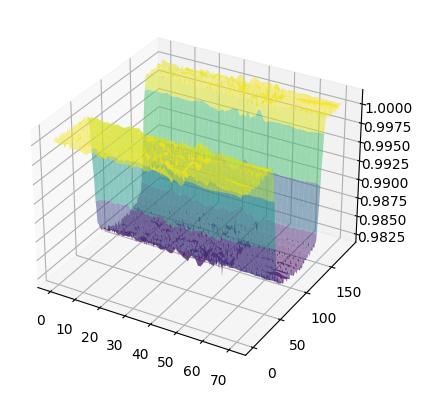

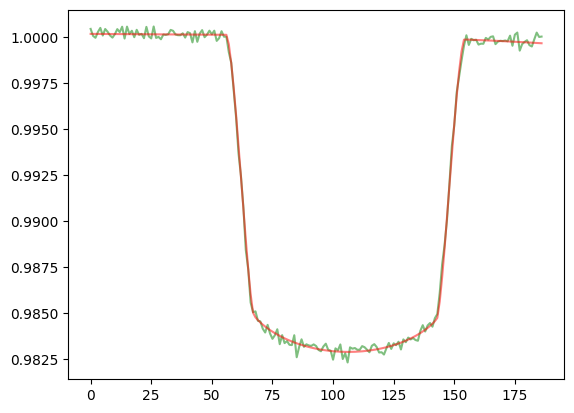

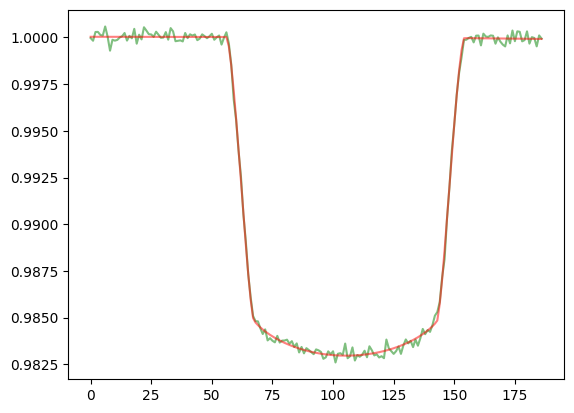

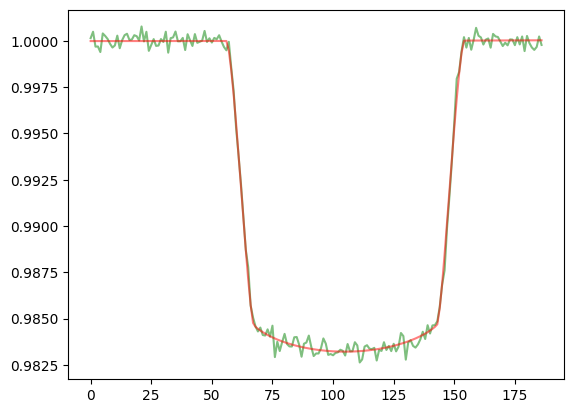

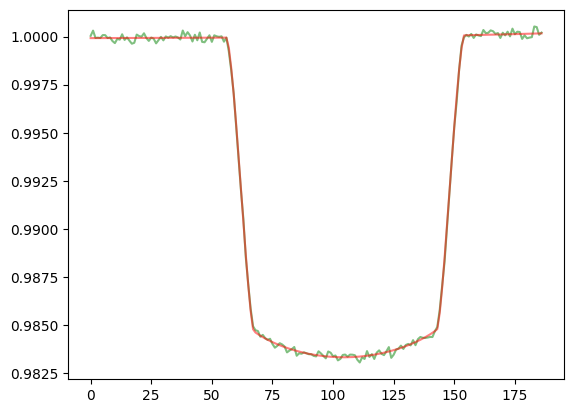

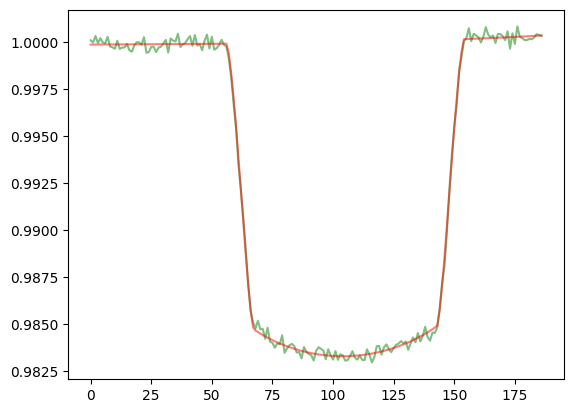

airs_popt :  (369,)
fgs1_popt :  (13,)


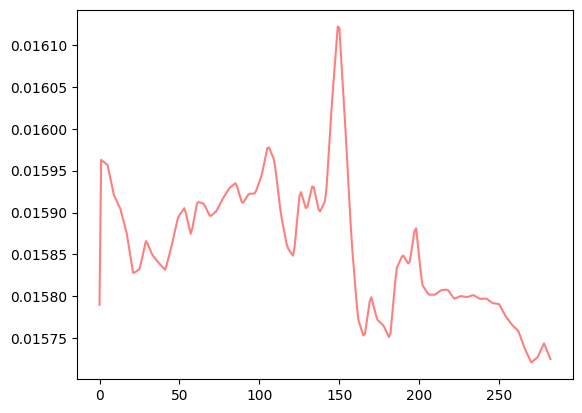

   planet_id        Rs      Ms          Ts        Mp    e         P       sma  \
0  1103775.0  0.965432  0.9591  5539.03037  1.665007  0.0  6.932871  15.43293   

           i  
0  89.533139  


In [12]:
def area(d, x, R):
    _area = np.zeros_like(d + x, dtype = float)

    mask1 = (d <= np.abs(R - x))
    mask2 = (d > np.abs(R - x)) & (d < (R + x))

    _area[mask1] = (np.pi * (np.minimum(x, R) ** 2))[mask1]

    with np.errstate(divide = 'ignore', invalid = 'ignore'):
        arg1 = (d ** 2 + x ** 2 - R ** 2) / (2 * d * x)
        arg2 = (d ** 2 + R ** 2 - x ** 2) / (2 * d * R)
        arg3 = (-d + x + R) * (d + x - R) * (d - x + R) * (d + x + R)

    arg1 = np.clip(arg1, -1, 1)
    arg2 = np.clip(arg2, -1, 1)
    arg3 = np.clip(arg3, 0, None)

    _area[mask2] = (x ** 2 * np.arccos(arg1) + R ** 2 * np.arccos(arg2) - 0.5 * np.sqrt(arg3))[mask2]
    return _area

def intensity(x, args):
    c1, c2, c3, c4 = args

    norm = (- c1 / 10 - c2 / 6 - 3 * c3 / 14 - c4 / 4 + 0.5) * 2 * np.pi

    x = np.clip(x, None, 0.99995)
    sqrtmu = (1 - x ** 2) ** 0.25
    return (1 - c1 * (1 - sqrtmu) - c2 * (1 - sqrtmu ** 2) - c3 * (1 - sqrtmu ** 3) - c4 * (1 - sqrtmu ** 4)) / norm

def calc_limb_darkening(d_array, rprs, intensity_args, n_step = 5):
    f_array = np.ones_like(d_array, dtype = float)

    x_in_array  = np.maximum(d_array - rprs, 0.0)
    x_out_array = np.minimum(d_array + rprs, 1.0)

    mask = (x_in_array < 1.0) & ((x_out_array - x_in_array) >= 1e-7)

    if not np.any(mask):
        return f_array

    d = d_array[mask]
    x_in = x_in_array[mask]
    x_out = x_out_array[mask]

    x = np.linspace(x_in, x_out, n_step, axis = 1)
    dx = x[:, 1:] - x[:, :-1]

    Int = intensity(x[:, 1:] - dx / 2, intensity_args)

    A = area(d[:, np.newaxis], x, rprs)
    delta = np.sum((A[:, 1:] - A[:, :-1]) * Int, axis = 1)

    f_array[mask] = 1.0 - delta
    return f_array

def get_transit(t, star_info, rp, c1, c2, c3, c4, P, sma, i, t0):
    f = 2 * np.pi * (t - t0) / P
    b = sma * np.cos(np.radians(i))
    d = np.sqrt((sma * np.sin(f)) ** 2 + (b * np.cos(f)) ** 2)

    transit = calc_limb_darkening(d, rp, [c1, c2, c3, c4])
    return transit

def get_system(t, c, *coeffs):
    system_time = Polynomial(coeffs[:len(coeffs) // 2])(t)
    system_channel = Polynomial(coeffs[len(coeffs) // 2:])(c)

    system = system_time[:, None] * system_channel[None, :]
    system = 1 + system
    return system

def get_jac_sparsity(param_info, n_time, n_channel):
    m = n_time * n_channel
    n = param_info['n_param']

    jac_sparsity = lil_matrix((m, n), dtype = int)
    for param in ['P', 'sma', 'i', 't0', 'sys']:
        start = param_info[param][0]
        end = param_info[param][1]
        jac_sparsity[:, start:end] = 1

    for param in ['rp', 'c1', 'c2', 'c3', 'c4']:
        for j in range(n_channel):
            jac_sparsity[
                np.arange(j, m, n_channel),
                param_info[param][0] + j,
            ] = 1
            
    return jac_sparsity

def model2(params, t, star_info, param_info, n_channel):
    c = np.linspace(0, 1, n_channel)

    rp = params[param_info['rp'][0]:param_info['rp'][1]]

    c1 = ((np.tanh(params[param_info['c1'][0]:param_info['c1'][1]]) + 1.0) / 2) * param_info['ci_max']
    c2 = ((np.tanh(params[param_info['c2'][0]:param_info['c2'][1]]) + 1.0) / 2) * param_info['ci_max']
    c3 = ((np.tanh(params[param_info['c3'][0]:param_info['c3'][1]]) + 1.0) / 2) * param_info['ci_max']
    c4 = ((np.tanh(params[param_info['c4'][0]:param_info['c4'][1]]) + 1.0) / 2) * param_info['ci_max']
    
    P = params[param_info['P'][0]:param_info['P'][1]]
    sma = params[param_info['sma'][0]:param_info['sma'][1]]
    i = params[param_info['i'][0]:param_info['i'][1]]
    t0 = params[param_info['t0'][0]:param_info['t0'][1]]

    sys = params[param_info['sys'][0]:param_info['sys'][1]]

    transit = []
    for j in range(n_channel):
        _transit = get_transit(t, star_info, rp[j], c1[j], c2[j], c3[j], c4[j], P, sma, i, t0)
        transit.append(_transit)

    transit = np.stack(transit, axis = 1)
    system = get_system(t, c, *sys)

    pred = transit * system
    return pred

def fun(params, t, star_info, param_info, true):
    n_channel = true.shape[1]

    pred = model2(params, t, star_info, param_info, n_channel)
    loss = true - pred
    return loss.ravel()

def process_single(inputs):
    args, ydata, time, star_info, T1, T2, T3, T4, degree, window, ci_max = inputs

    system_mask = (time < T1) | (time > T4)
    transit_mask = (time > T2) & (time < T3)

    target = ydata[:, 0]
    target /= target[system_mask].mean()

    def model(t, star_info, rp, c1, c2, c3, c4, P, sma, i, t0, *coeffs):
        f = 2 * np.pi * (t - t0) / P
        b = sma * np.cos(np.radians(i))
        d = np.sqrt((sma * np.sin(f)) ** 2 + (b * np.cos(f)) ** 2)

        system = Polynomial(coeffs)(t)
        transit = calc_limb_darkening(d, rp, [c1, c2, c3, c4])
        return system, transit

    def f(xdata, rp, c1, c2, c3, c4, P, sma, i, t0, *coeffs):
        system, transit = model(xdata, star_info, rp, c1, c2, c3, c4, P, sma, i, t0, *coeffs)
        return system * transit

    rp_0 = np.sqrt(1 - target[transit_mask].mean())

    ci_0 = [1e-1] * 4

    P_0 = star_info['P'] * 24 / 7.5
    sma_0 = star_info['sma']
    i_0 = star_info['i']
    t0_0 = (T1 + T4) / 2

    sysi_0 = [0] * (degree + 1)

    p0 = [rp_0] + ci_0 + [P_0, sma_0, i_0, t0_0] + sysi_0
    bounds = (
        [rp_0 * (1.0 - 1e-1)] + [0.0] * 4 + [_ * (1.0 - 1e-1) for _ in [P_0, sma_0, i_0, t0_0]] + [-1e1] * (degree + 1),
        [rp_0 * (1.0 + 1e-1)] + [ci_max] * 4 + [_ * (1.0 + 1e-1) for _ in [P_0, sma_0, i_0, t0_0]] + [+1e1] * (degree + 1),
    )

    popt, pcov = curve_fit(
        f = f,
        xdata = time,
        ydata = target,
        p0 = p0,
        bounds = bounds,
    )
    return popt

def process_multiple(inputs):
    args, targets, time, star_info, T1, T2, T3, T4, sysi_degree, window, ci_max, plot, params, param_info = inputs

    system_mask = (time < T1) | (time > T4)
    transit_mask = (time > T2) & (time < T3)

    if params == None:
        rp_0 = np.sqrt(1 - targets[transit_mask].mean(0)).tolist()
    
        #ci_0 = [-1.0] * targets.shape[1] * 4
        ######################################
        ci_0 = [-0.5] * targets.shape[1] * 4
        ######################################
        
        P_0 = [star_info['P'] * 24 / 7.5]
        sma_0 = [star_info['sma']]
        i_0 = [star_info['i']]
        t0_0 = [(T1 + T4) / 2]
    
        sysi_0 = [1e-3] * (sysi_degree + 1) + [1e-3] * (sysi_degree + 1)
    
        x0 = rp_0 + ci_0 + P_0 + sma_0 + i_0 + t0_0 + sysi_0
    
        bounds = (
            [_ * (1.0 - 1e-1) for _ in rp_0] + [-1e1] * len(ci_0) + [_ * (1.0 - 2e-1) for _ in P_0 + sma_0 + i_0 + t0_0] + [-1e1] * len(sysi_0),
            [_ * (1.0 + 1e-1) for _ in rp_0] + [+1e1] * len(ci_0) + [_ * (1.0 + 2e-1) for _ in P_0 + sma_0 + i_0 + t0_0] + [+1e1] * len(sysi_0),
        )
    else:
        params = params.x
        
        rp_0 = params[param_info['rp'][0]:param_info['rp'][1]].tolist()
    
        c1_0 = params[param_info['c1'][0]:param_info['c1'][1]].tolist()
        c2_0 = params[param_info['c2'][0]:param_info['c2'][1]].tolist()
        c3_0 = params[param_info['c3'][0]:param_info['c3'][1]].tolist()
        c4_0 = params[param_info['c4'][0]:param_info['c4'][1]].tolist()
    
        ci_0 = c1_0 + c2_0 + c3_0 + c4_0
        
        P_0 = params[param_info['P'][0]:param_info['P'][1]].tolist()
        sma_0 = params[param_info['sma'][0]:param_info['sma'][1]].tolist()
        i_0 = params[param_info['i'][0]:param_info['i'][1]].tolist()
        t0_0 = params[param_info['t0'][0]:param_info['t0'][1]].tolist()
    
        sysi_0 = params[param_info['sys'][0]:param_info['sys'][1]].tolist()
        sysi_0 = [1e-3] * (sysi_degree - param_info['sysi_degree']) + sysi_0[:param_info['sysi_degree'] + 1] + \
                 [1e-3] * (sysi_degree - param_info['sysi_degree']) + sysi_0[param_info['sysi_degree'] + 1:]

        x0 = rp_0 + ci_0 + P_0 + sma_0 + i_0 + t0_0 + sysi_0

        bounds = (
            [_ * (1.0 - 1e-1) for _ in rp_0] + [-1e1] * len(ci_0) + [_ * (1.0 - 1e-1) for _ in P_0 + sma_0 + i_0 + t0_0] + [-1e1] * len(sysi_0),
            [_ * (1.0 + 1e-1) for _ in rp_0] + [+1e1] * len(ci_0) + [_ * (1.0 + 1e-1) for _ in P_0 + sma_0 + i_0 + t0_0] + [+1e1] * len(sysi_0),
        )

    param_info = {
        'rp' : [0, len(rp_0)],
        'c1' : [len(rp_0), len(rp_0) + (len(ci_0) // 4)],
        'c2' : [len(rp_0) + (len(ci_0) // 4), len(rp_0) + 2 * (len(ci_0) // 4)],
        'c3' : [len(rp_0) + 2 * (len(ci_0) // 4), len(rp_0) + 3 * (len(ci_0) // 4)],
        'c4' : [len(rp_0) + 3 * (len(ci_0) // 4), len(rp_0) + len(ci_0)],
        'P' : [len(rp_0) + len(ci_0), len(rp_0) + len(ci_0) + 1],
        'sma' : [len(rp_0) + len(ci_0) + 1, len(rp_0) + len(ci_0) + 2],
        'i' : [len(rp_0) + len(ci_0) + 2, len(rp_0) + len(ci_0) + 3],
        't0' : [len(rp_0) + len(ci_0) + 3, len(rp_0) + len(ci_0) + 4],
        'sys' : [len(rp_0) + len(ci_0) + 4, len(rp_0) + len(ci_0) + 4 + len(sysi_0)],
        'n_param' : len(rp_0) + len(ci_0) + 4 + len(sysi_0),
        'ci_max' : ci_max,
        'sysi_degree' : sysi_degree,
    }

    jac_sparsity = get_jac_sparsity(param_info, targets.shape[0], targets.shape[1])

    with Pool(processes = os.cpu_count()) as pool:
        res = least_squares(
            fun = fun,
            x0 = x0,
            bounds = bounds,
            method = 'trf',
            jac_sparsity = jac_sparsity,
            args = (time, star_info, param_info, targets),
            workers = pool.map,
            verbose = 2 if plot else 0,
        )
    return res, param_info

def stage2_function(args, ydata, star_info, T1, T2, T3, T4, ci_max = 0.5, sysi_degree = 3, window = 5, downsample = 4, plot = False):
    time = np.linspace(0, 1, ydata.shape[0])

    system_mask = (time < T1) | (time > T4)
    transit_mask = (time > T2) & (time < T3)

    targets = []
    for j in range(ydata.shape[1]):
        if j > 200:
            window = 50
        
        if j == 0:
            target = ydata[:, 0:1]
        else:
            target = ydata[:, max(1, j - window):(j + window + 1)]

        target = target.mean(1)
        target /= target[system_mask].mean()
        targets.append(target)

    targets = np.stack(targets, axis = 1)
    targets = targets[:, 1::downsample]

    #res, param_info = process_multiple([args, targets, time, star_info, T1, T2, T3, T4, 3, 5, 0.50, plot, None, None])
    #res, param_info = process_multiple([args, targets, time, star_info, T1, T2, T3, T4, 4, 5, 0.50, plot, res, param_info])
    ###########################################################################################################################
    res, param_info = process_multiple([args, targets, time, star_info, T1, T2, T3, T4, 3, 5, 0.25, plot, None, None])
    res, param_info = process_multiple([args, targets, time, star_info, T1, T2, T3, T4, 4, 5, 0.25, plot, res, param_info])
    ###########################################################################################################################
    airs_popt, cost, nfev = res.x, res.cost, res.nfev
    
    fgs1_popt = process_single([args, ydata, time, star_info, T1, T2, T3, T4, 3, 5, 0.5])

    means = np.array(airs_popt[param_info['rp'][0]:param_info['rp'][1]]) ** 2
    x1 = np.linspace(0, 1, 282)
    x2 = np.linspace(0, 1, means.shape[0])
    means = np.interp(x1, x2, means).tolist()
    means = [fgs1_popt[0] ** 2] + means

    sigmas = [args.fgs_sigma] + [args.sigma] * 282

    pred = np.array(means + sigmas)
    pred = pred.clip(0)

    params = np.concatenate([
        airs_popt,
        np.array([cost]),
        np.array([nfev]),
        fgs1_popt,
    ], axis = 0)

    if plot:
        x1, x2 = np.meshgrid(
            np.linspace(0, targets.shape[1], targets.shape[1]),
            np.linspace(0, targets.shape[0], targets.shape[0]),
        )
        fig = plt.figure()
        ax = fig.add_subplot(projection = '3d')
        ax.plot_surface(x1, x2, targets, cmap = 'viridis', color = 'g', alpha = 0.5)
        plt.show()

        _pred = model2(airs_popt, time, star_info, param_info, targets.shape[1])

        for j in range(targets.shape[1]):
            if j % (targets.shape[1] // 4) == 0:
                plt.plot(targets[:, j], color = 'g', alpha = 0.5)
                plt.plot(_pred[:, j], color = 'r', alpha = 0.5)
                plt.show()

        print('airs_popt : ', airs_popt.shape)
        print('fgs1_popt : ', fgs1_popt.shape)

    return pred, params

if __name__ == '__main__':
    train_star_info = pd.read_csv('/kaggle/input/ariel-data-challenge-2025/train_star_info.csv')
    test_star_info = pd.read_csv('/kaggle/input/ariel-data-challenge-2025/test_star_info.csv')

    if args.split == 'train':
        if '2024' in args.root:
            train = pd.read_csv('/kaggle/input/ariel-data-challenge-2024/train_labels.csv')
        else:
            train = pd.read_csv('/kaggle/input/ariel-data-challenge-2025/train.csv')

        cv6 = pd.read_csv('/kaggle/input/nips-adc-data/cv6.csv')
        cv7 = pd.read_csv('/kaggle/input/nips-adc-data/cv7.csv')

        true = train[train.planet_id == int(planet_id)].values[0, 1:]
        star_info = dict(train_star_info[train_star_info.planet_id == int(planet_id)].reset_index(drop = True).loc[0])
        pred, stage2_params = stage2_function(args, data, star_info, *stage1_params[:4], plot = True)

        plt.plot(true, color = 'g', alpha = 0.5)
        plt.plot(cv6[cv6.planet_id == int(planet_id)].values[0, 1:1 + 283], color = 'c', alpha = 0.5)
        plt.plot(cv7[cv7.planet_id == int(planet_id)].values[0, 1:1 + 283], color = 'y', alpha = 0.5)
        plt.plot(pred[:283], color = 'r', alpha = 0.5)
        plt.show()

        submission = pd.DataFrame(pred[None], columns = args.columns)
        submission['planet_id'] = [int(planet_id)]
        _, _, score = get_score(args, submission)

        print('score : ', score)
        print('cv6 : ', cv6[cv6.planet_id == int(planet_id)]['weighted_score'].values[0])
        print('cv7 : ', cv7[cv7.planet_id == int(planet_id)]['weighted_score'].values[0])
        print('params : ', stage2_params.shape)

        print(train_star_info[train_star_info.planet_id == int(planet_id)])
    else:
        star_info = dict(test_star_info[test_star_info.planet_id == int(planet_id)].reset_index(drop = True).loc[0])

        pred, stage2_params = stage2_function(args, data, star_info, *stage1_params[:4], plot = True)

        plt.plot(pred[:283], color = 'r', alpha = 0.5)
        plt.show()

        print(test_star_info[test_star_info.planet_id == int(planet_id)])

### postprocess

In [13]:
"""def postprocess_function(args, models, submission, star_info, success, stage1_params, stage2_params):
    inputs = get_inputs(args, submission, star_info.loc[submission.planet_id], stage1_params, stage2_params)

    pred = []
    for model in models:
        pred.append(model.predict(inputs))
    pred = np.stack(pred, axis = 0).mean(0)
    pred = pred.clip(args.post_sigma[0])

    submission.loc[success, [f'sigma_{c}' for c in range(2, 283 + 1)]] = np.broadcast_to(pred[:, np.newaxis], (pred.shape[0], 282))[success]
    submission.loc[success, ['sigma_1']] = 2 * pred[success]

    if args.pca_components != None:
        submission.loc[success, [f'wl_{c}' for c in range(2, 283 + 1)]] = pca_function(
            submission.loc[success, [f'wl_{c}' for c in range(2, 283 + 1)]].values, args.pca_components
        ).clip(0)
    return submission

def get_inputs(args, df, star_info, stage1_params = None, stage2_params = None):
    if isinstance(stage1_params, np.ndarray):
        T = stage1_params[:, :4]
    else:
        T = df[['T1', 'T2', 'T3', 'T4']].values

    param_info = {
        'airs' : {
            'rp': [0, 71], 
            'c1': [71, 142], 
            'c2': [142, 213], 
            'c3': [213, 284], 
            'c4': [284, 355], 
            'P': [355, 356], 
            'sma': [356, 357], 
            'i': [357, 358], 
            't0': [358, 359], 
            'sys': [359, 369], 
        },
        'cost' : [369, 370], 
        'nfev' : [370, 371], 
        'fgs1' : {
            'rp': [371, 372], 
            'c1': [372, 373], 
            'c2': [373, 374], 
            'c3': [374, 375], 
            'c4': [375, 376], 
            'P': [376, 377], 
            'sma': [377, 378], 
            'i': [378, 379], 
            't0': [379, 380], 
            'sys': [380, 384], 
        },
    }

    if isinstance(stage2_params, np.ndarray):
        pass

    else:
        stage2_params = np.concatenate([
            df[[f'airs_popt_{c}' for c in range(1, 1 + 369)]].values,
            df[['cost', 'nfev']].values,
            df[[f'fgs1_popt_{c}' for c in range(1, 1 + 13)]].values,
        ], axis = 1)

    rp = np.concatenate([
        stage2_params[:, param_info['airs']['rp'][0]:param_info['airs']['rp'][1]],
        stage2_params[:, param_info['fgs1']['rp'][0]:param_info['fgs1']['rp'][1]],
    ], axis = 1)

    c1 = np.concatenate([
        stage2_params[:, param_info['airs']['c1'][0]:param_info['airs']['c1'][1]],
        stage2_params[:, param_info['fgs1']['c1'][0]:param_info['fgs1']['c1'][1]],
    ], axis = 1)

    c2 = np.concatenate([
        stage2_params[:, param_info['airs']['c2'][0]:param_info['airs']['c2'][1]],
        stage2_params[:, param_info['fgs1']['c2'][0]:param_info['fgs1']['c2'][1]],
    ], axis = 1)

    c3 = np.concatenate([
        stage2_params[:, param_info['airs']['c3'][0]:param_info['airs']['c3'][1]],
        stage2_params[:, param_info['fgs1']['c3'][0]:param_info['fgs1']['c3'][1]],
    ], axis = 1)

    c4 = np.concatenate([
        stage2_params[:, param_info['airs']['c4'][0]:param_info['airs']['c4'][1]],
        stage2_params[:, param_info['fgs1']['c4'][0]:param_info['fgs1']['c4'][1]],
    ], axis = 1)

    P = np.concatenate([
        stage2_params[:, param_info['airs']['P'][0]:param_info['airs']['P'][1]],
        stage2_params[:, param_info['fgs1']['P'][0]:param_info['fgs1']['P'][1]],
    ], axis = 1)
    
    sma = np.concatenate([
        stage2_params[:, param_info['airs']['sma'][0]:param_info['airs']['sma'][1]],
        stage2_params[:, param_info['fgs1']['sma'][0]:param_info['fgs1']['sma'][1]],
    ], axis = 1)
    
    i = np.concatenate([
        stage2_params[:, param_info['airs']['i'][0]:param_info['airs']['i'][1]],
        stage2_params[:, param_info['fgs1']['i'][0]:param_info['fgs1']['i'][1]],
    ], axis = 1)
    
    t0 = np.concatenate([
        stage2_params[:, param_info['airs']['t0'][0]:param_info['airs']['t0'][1]],
        stage2_params[:, param_info['fgs1']['t0'][0]:param_info['fgs1']['t0'][1]],
    ], axis = 1)

    cost = stage2_params[:, param_info['cost'][0]:param_info['cost'][1]]
    nfev = stage2_params[:, param_info['nfev'][0]:param_info['nfev'][1]]

    inputs = np.concatenate([
        T,
        T[:, 3:4] - T[:, 0:1],
        T[:, 2:3] - T[:, 1:2],

        rp[:, :-1].mean(1, keepdims = True),
        c1[:, :-1].mean(1, keepdims = True),
        c2[:, :-1].mean(1, keepdims = True),
        c3[:, :-1].mean(1, keepdims = True),
        c4[:, :-1].mean(1, keepdims = True),

        rp[:, :-1].std(1, keepdims = True),
        c1[:, :-1].std(1, keepdims = True),
        c2[:, :-1].std(1, keepdims = True),
        c3[:, :-1].std(1, keepdims = True),
        c4[:, :-1].std(1, keepdims = True),

        #P,
        #sma,
        #i,
        #t0,

        cost,
        nfev,

        star_info.values,
    ], axis = 1)
    return inputs

def get_targets(args, df, star_info, label):
    _targets = df['target'].values

    targets = []
    for j in range(_targets.shape[0]):
        targets.append(args.post_sigma[_targets[j]])

    targets = np.stack(targets, axis = 0)
    return targets

def train_function(args, df):
    print('n_train : ', len(df))

    star_info = pd.read_csv(args.root + f'train_star_info.csv')
    star_info = star_info.set_index('planet_id')

    label = pd.read_csv(args.root + 'train.csv')
    label = label.set_index('planet_id')

    planet_ids = df.planet_id.unique()

    solution = get_solution(args, label.reset_index(), planet_ids)

    #'''
    for j in range(len(df)):
        df.loc[j, [f'wl_{c}' for c in range(2, 283 + 1)]] = gaussian_filter1d(
            df.loc[j, [f'wl_{c}' for c in range(2, 283 + 1)]].values.astype(float), sigma = 1.0,
        ).clip(0)
    #'''

    targets = []
    for sigma in args.post_sigma:
        _df = df.copy()
        _df.loc[:, [f'sigma_{c}' for c in range(2, 283 + 1)]] = sigma
        _df.loc[:, 'sigma_1'] = 2.0 * sigma

        scores, _, _ = get_score(args, _df[_df.columns[:567]], solution = solution, print_score = False)
        targets.append(scores)

    targets = np.stack(targets, axis = 1)
    targets = targets.argmax(1)

    df['target'] = targets

    if args.post_wl != None:
        df.loc[:, [f'wl_{c}' for c in range(2, 283 + 1)]] *= (1.0 + args.post_wl[0])
        df.loc[:, ['wl_1']] *= (1.0 + args.post_wl[1])

    outputs = {}

    kf = KFold(n_splits = args.n_fold, shuffle = True, random_state = args.seed)
    for i, (train_index, test_index) in enumerate(kf.split(planet_ids)):
        train_planets = planet_ids[train_index]
        test_planets = planet_ids[test_index]

        train_df = df[(df.planet_id.isin(train_planets)) & (df.success == True)].reset_index(drop = True)
        test_df = df[df.planet_id.isin(test_planets)].reset_index(drop = True)

        train_star_info = star_info.loc[train_df.planet_id]
        test_star_info = star_info.loc[test_planets]

        train_label = label.loc[train_df.planet_id]
        test_label = label.loc[test_planets]

        train_inputs = get_inputs(args, train_df, train_star_info)
        train_targets = get_targets(args, train_df, train_star_info, train_label)

        test_inputs = get_inputs(args, test_df, test_star_info)
        test_targets = get_targets(args, test_df, test_star_info, test_label)

        model = GradientBoostingRegressor(
            random_state = args.seed,
            n_estimators = 250,
            max_depth = 3,
        )

        model.fit(train_inputs, train_targets)

        score = model.score(test_inputs, test_targets)

        print(f'fold{i + 1}', score)

        outputs[f'fold{i + 1}'] = {}
        outputs[f'fold{i + 1}']['train_planets'] = train_planets
        outputs[f'fold{i + 1}']['test_planets'] = test_planets
        outputs[f'fold{i + 1}']['model'] = model
        outputs[f'fold{i + 1}']['score'] = score

    return outputs

def get_cv(args, df):
    outputs = train_function(args, df)

    star_info = pd.read_csv(args.root + f'train_star_info.csv')
    star_info = star_info.set_index('planet_id')

    cv = []
    scores = []
    for i in range(args.n_fold):
        output = outputs[f'fold{i + 1}']

        planet_ids = output['test_planets']

        _df = df.loc[df.planet_id.isin(planet_ids)]
        _df = _df.reset_index(drop = True)

        success = _df['success'].values
        stage1_params = _df[['T1', 'T2', 'T3', 'T4']].values
        stage2_params = np.concatenate([
            _df[[f'airs_popt_{c}' for c in range(1, 1 + 369)]].values,
            _df[['cost', 'nfev']].values,
            _df[[f'fgs1_popt_{c}' for c in range(1, 1 + 13)]].values,
        ], axis = 1)

        if args.postprocess:
            _df = postprocess_function(args, [output['model']], _df, star_info.loc[_df.planet_id], success, stage1_params, stage2_params)

        weighted_scores, _, score = get_score(args, _df[_df.columns[:567]], print_score = False)
        _df['weighted_score'] = weighted_scores
        _df['fold'] = [i + 1] * len(_df)

        cv.append(_df)
        scores.append(score)

    cv = pd.concat(cv, axis = 0)
    cv = cv.reset_index(drop = True)
    return cv, scores, outputs

if __name__ == '__main__':
    args = CustomConfig()

    args.cv_path = '/kaggle/input/nips-adc-data/cv6.csv'

    args.postprocess = True
    args.post_wl = [1e-3, -5e-3]
    args.post_sigma = np.linspace(5e-5, 2e-3, 500)

    args.pca_components = 6

    df = pd.read_csv(args.cv_path)
    df['planet_id'] = df['planet_id'].astype(int)
    df = df[~df.planet_id.isin([2486733311])]
    df = df.sort_values(by = 'planet_id')
    df = df.reset_index(drop = True)

    df, scores, _ = get_cv(args, df)
    print('scores : ', scores)
    print('cv : ', np.mean(scores))

    df.to_csv('cv.csv', index = False)

    '''
    n_train :  1099
    fold1 0.3815623750338394
    fold2 0.1702556503990037
    fold3 0.6332230605037319
    fold4 0.7112889028015135
    scores :  [0.5901795315417878, 0.5731021979279475, 0.5937740064245882, 0.5807180647396613]
    cv :  0.5844434501584962
    '''"""
pass

In [14]:
def postprocess_function(args, models, submission, star_info, success, stage1_params, stage2_params):
    inputs = get_inputs(args, submission, star_info.loc[submission.planet_id], stage1_params, stage2_params)

    pred = []
    for model in models:
        pred.append(model.predict(inputs))
    pred = np.stack(pred, axis = 0).mean(0)
    pred = pred.clip(args.post_sigma[0])

    submission.loc[success, [f'sigma_{c}' for c in range(2, 283 + 1)]] = np.broadcast_to(pred[:, np.newaxis], (pred.shape[0], 282))[success]
    submission.loc[success, ['sigma_1']] = 2 * pred[success]

    if args.pca_components != None:
        submission.loc[success, [f'wl_{c}' for c in range(2, 283 + 1)]] = pca_function(
            submission.loc[success, [f'wl_{c}' for c in range(2, 283 + 1)]].values, args.pca_components
        ).clip(0)

    ############################################################################################
    cost = stage2_params[:, 369]
    submission.loc[cost > 1e-3, [f'sigma_{c}' for c in range(1, 283 + 1)]] = args.naive_sigma
    ############################################################################################
    return submission

def get_inputs(args, df, star_info, stage1_params = None, stage2_params = None):
    if isinstance(stage1_params, np.ndarray):
        T = stage1_params[:, :4]
    else:
        T = df[['T1', 'T2', 'T3', 'T4']].values

    param_info = {
        'airs' : {
            'rp': [0, 71], 
            'c1': [71, 142], 
            'c2': [142, 213], 
            'c3': [213, 284], 
            'c4': [284, 355], 
            'P': [355, 356], 
            'sma': [356, 357], 
            'i': [357, 358], 
            't0': [358, 359], 
            'sys': [359, 369], 
        },
        'cost' : [369, 370], 
        'nfev' : [370, 371], 
        'fgs1' : {
            'rp': [371, 372], 
            'c1': [372, 373], 
            'c2': [373, 374], 
            'c3': [374, 375], 
            'c4': [375, 376], 
            'P': [376, 377], 
            'sma': [377, 378], 
            'i': [378, 379], 
            't0': [379, 380], 
            'sys': [380, 384], 
        },
    }

    if isinstance(stage2_params, np.ndarray):
        pass

    else:
        stage2_params = np.concatenate([
            df[[f'airs_popt_{c}' for c in range(1, 1 + 369)]].values,
            df[['cost', 'nfev']].values,
            df[[f'fgs1_popt_{c}' for c in range(1, 1 + 13)]].values,
        ], axis = 1)

    rp = np.concatenate([
        stage2_params[:, param_info['airs']['rp'][0]:param_info['airs']['rp'][1]],
        stage2_params[:, param_info['fgs1']['rp'][0]:param_info['fgs1']['rp'][1]],
    ], axis = 1)

    c1 = np.concatenate([
        stage2_params[:, param_info['airs']['c1'][0]:param_info['airs']['c1'][1]],
        stage2_params[:, param_info['fgs1']['c1'][0]:param_info['fgs1']['c1'][1]],
    ], axis = 1)

    c2 = np.concatenate([
        stage2_params[:, param_info['airs']['c2'][0]:param_info['airs']['c2'][1]],
        stage2_params[:, param_info['fgs1']['c2'][0]:param_info['fgs1']['c2'][1]],
    ], axis = 1)

    c3 = np.concatenate([
        stage2_params[:, param_info['airs']['c3'][0]:param_info['airs']['c3'][1]],
        stage2_params[:, param_info['fgs1']['c3'][0]:param_info['fgs1']['c3'][1]],
    ], axis = 1)

    c4 = np.concatenate([
        stage2_params[:, param_info['airs']['c4'][0]:param_info['airs']['c4'][1]],
        stage2_params[:, param_info['fgs1']['c4'][0]:param_info['fgs1']['c4'][1]],
    ], axis = 1)

    P = np.concatenate([
        stage2_params[:, param_info['airs']['P'][0]:param_info['airs']['P'][1]],
        stage2_params[:, param_info['fgs1']['P'][0]:param_info['fgs1']['P'][1]],
    ], axis = 1)
    
    sma = np.concatenate([
        stage2_params[:, param_info['airs']['sma'][0]:param_info['airs']['sma'][1]],
        stage2_params[:, param_info['fgs1']['sma'][0]:param_info['fgs1']['sma'][1]],
    ], axis = 1)
    
    i = np.concatenate([
        stage2_params[:, param_info['airs']['i'][0]:param_info['airs']['i'][1]],
        stage2_params[:, param_info['fgs1']['i'][0]:param_info['fgs1']['i'][1]],
    ], axis = 1)
    
    t0 = np.concatenate([
        stage2_params[:, param_info['airs']['t0'][0]:param_info['airs']['t0'][1]],
        stage2_params[:, param_info['fgs1']['t0'][0]:param_info['fgs1']['t0'][1]],
    ], axis = 1)

    cost = stage2_params[:, param_info['cost'][0]:param_info['cost'][1]]
    nfev = stage2_params[:, param_info['nfev'][0]:param_info['nfev'][1]]

    inputs = np.concatenate([
        T,
        T[:, 3:4] - T[:, 0:1],
        T[:, 2:3] - T[:, 1:2],

        rp[:, :-1].mean(1, keepdims = True),
        c1[:, :-1].mean(1, keepdims = True),
        c2[:, :-1].mean(1, keepdims = True),
        c3[:, :-1].mean(1, keepdims = True),
        c4[:, :-1].mean(1, keepdims = True),

        rp[:, :-1].std(1, keepdims = True),
        c1[:, :-1].std(1, keepdims = True),
        c2[:, :-1].std(1, keepdims = True),
        c3[:, :-1].std(1, keepdims = True),
        c4[:, :-1].std(1, keepdims = True),

        #P,
        #sma,
        #i,
        #t0,

        cost,
        nfev,

        star_info.values,
    ], axis = 1)
    return inputs

def get_targets(args, df, star_info, label):
    _targets = df['target'].values

    targets = []
    for j in range(_targets.shape[0]):
        targets.append(args.post_sigma[_targets[j]])

    targets = np.stack(targets, axis = 0)
    return targets

def train_function(args, df):
    print('n_train : ', len(df))

    star_info = pd.read_csv(args.root + f'train_star_info.csv')
    star_info = star_info.set_index('planet_id')

    label = pd.read_csv(args.root + 'train.csv')
    label = label.set_index('planet_id')

    planet_ids = df.planet_id.unique()

    solution = get_solution(args, label.reset_index(), planet_ids)

    #'''
    for j in range(len(df)):
        df.loc[j, [f'wl_{c}' for c in range(2, 283 + 1)]] = gaussian_filter1d(
            df.loc[j, [f'wl_{c}' for c in range(2, 283 + 1)]].values.astype(float), sigma = 1.0,
        ).clip(0)
    #'''

    targets = []
    for sigma in args.post_sigma:
        _df = df.copy()
        _df.loc[:, [f'sigma_{c}' for c in range(2, 283 + 1)]] = sigma
        _df.loc[:, 'sigma_1'] = 2.0 * sigma

        scores, _, _ = get_score(args, _df[_df.columns[:567]], solution = solution, print_score = False)
        targets.append(scores)

    targets = np.stack(targets, axis = 1)
    targets = targets.argmax(1)

    df['target'] = targets

    if args.post_wl != None:
        df.loc[:, [f'wl_{c}' for c in range(2, 283 + 1)]] *= (1.0 + args.post_wl[0])
        df.loc[:, ['wl_1']] *= (1.0 + args.post_wl[1])

    outputs = {}

    kf = KFold(n_splits = args.n_fold, shuffle = True, random_state = args.seed)
    for i, (train_index, test_index) in enumerate(kf.split(planet_ids)):
        train_planets = planet_ids[train_index]
        test_planets = planet_ids[test_index]

        train_df = df[(df.planet_id.isin(train_planets)) & (df.success == True)].reset_index(drop = True)
        test_df = df[df.planet_id.isin(test_planets)].reset_index(drop = True)

        train_star_info = star_info.loc[train_df.planet_id]
        test_star_info = star_info.loc[test_planets]

        train_label = label.loc[train_df.planet_id]
        test_label = label.loc[test_planets]

        train_inputs = get_inputs(args, train_df, train_star_info)
        train_targets = get_targets(args, train_df, train_star_info, train_label)

        test_inputs = get_inputs(args, test_df, test_star_info)
        test_targets = get_targets(args, test_df, test_star_info, test_label)

        model = GradientBoostingRegressor(
            random_state = args.seed,
            n_estimators = 250,
            max_depth = 3,
        )

        model.fit(train_inputs, train_targets)

        score = model.score(test_inputs, test_targets)

        print(f'fold{i + 1}', score)

        outputs[f'fold{i + 1}'] = {}
        outputs[f'fold{i + 1}']['train_planets'] = train_planets
        outputs[f'fold{i + 1}']['test_planets'] = test_planets
        outputs[f'fold{i + 1}']['model'] = model
        outputs[f'fold{i + 1}']['score'] = score

    return outputs

def get_cv(args, df):
    outputs = train_function(args, df)

    star_info = pd.read_csv(args.root + f'train_star_info.csv')
    star_info = star_info.set_index('planet_id')

    cv = []
    scores = []
    for i in range(args.n_fold):
        output = outputs[f'fold{i + 1}']

        planet_ids = output['test_planets']

        _df = df.loc[df.planet_id.isin(planet_ids)]
        _df = _df.reset_index(drop = True)

        success = _df['success'].values
        stage1_params = _df[['T1', 'T2', 'T3', 'T4']].values
        stage2_params = np.concatenate([
            _df[[f'airs_popt_{c}' for c in range(1, 1 + 369)]].values,
            _df[['cost', 'nfev']].values,
            _df[[f'fgs1_popt_{c}' for c in range(1, 1 + 13)]].values,
        ], axis = 1)

        if args.postprocess:
            _df = postprocess_function(args, [output['model']], _df, star_info.loc[_df.planet_id], success, stage1_params, stage2_params)

        weighted_scores, _, score = get_score(args, _df[_df.columns[:567]], print_score = False)
        _df['weighted_score'] = weighted_scores
        _df['fold'] = [i + 1] * len(_df)

        cv.append(_df)
        scores.append(score)

    cv = pd.concat(cv, axis = 0)
    cv = cv.reset_index(drop = True)
    return cv, scores, outputs

if __name__ == '__main__':
    args = CustomConfig()

    args.cv_path = '/kaggle/input/nips-adc-data/cv7.csv'

    args.postprocess = True
    args.post_wl = [1e-3, -5e-3]
    args.post_sigma = np.linspace(5e-5, 2e-3, 500)

    args.pca_components = 6

    df = pd.read_csv(args.cv_path)
    df['planet_id'] = df['planet_id'].astype(int)
    df = df[~df.planet_id.isin([2486733311])]
    df = df.sort_values(by = 'planet_id')
    df = df.reset_index(drop = True)

    df, scores, _ = get_cv(args, df)
    print('scores : ', scores)
    print('cv : ', np.mean(scores))

    df.to_csv('cv.csv', index = False)

    '''
    n_train :  1099
    fold1 0.4019442588732902
    fold2 0.19470112562469788
    fold3 0.6993526840629687
    fold4 0.6067050563180972
    scores :  [0.5941109709164912, 0.567059423165547, 0.5899356784116865, 0.5787205122555714]
    cv :  0.5824566461873241
    '''

n_train :  1099
fold1 0.4019442588732902
fold2 0.19470112562469788
fold3 0.6993526840629687
fold4 0.6067050563180972
scores :  [0.5941109709164915, 0.5670594231655471, 0.5899356784116866, 0.5787205122555714]
cv :  0.5824566461873242


### run

In [15]:
def inference_function(args):
    planet_ids = glob.glob(args.root + f'{args.split}/*')
    planet_ids = sorted([int(_.split('/')[-1]) for _ in planet_ids])

    if args.split == 'train':
        planet_ids = planet_ids[::11][:1]

    star_info = pd.read_csv(args.root + f'{args.split}_star_info.csv')
    star_info = star_info.set_index('planet_id')
    star_info = star_info.loc[planet_ids]

    rows = []
    success = []
    stage1_params = []
    stage2_params = []
    for planet_id in tqdm(planet_ids):
        data = preprocess_function(args, planet_id)

        _success, _stage1_params = stage1_function(args, data)

        if _success:
            try:
                pred, _stage2_params = stage2_function(
                    args, 
                    data, 
                    dict(star_info.loc[int(planet_id)]),
                    *_stage1_params[:4],
                )  
                assert _stage2_params.shape == args.param_shape
            except:
                print(planet_id)
                pred = np.array([args.naive_mean] * 283 + [args.naive_sigma] * 283)
                _stage2_params = np.ones(args.param_shape)
        else:
            pred = np.array([args.naive_mean] * 283 + [args.naive_sigma] * 283)
            _stage2_params = np.ones(args.param_shape)
        
        row = {'planet_id' : planet_id}
        for i, column in enumerate(args.columns):
            row[column] = pred[i]

        rows.append(row)
        success.append(_success)
        stage1_params.append(_stage1_params)
        stage2_params.append(_stage2_params)
        
    submission = pd.DataFrame(rows)
    success = np.array(success)
    stage1_params = np.stack(stage1_params, axis = 0)
    stage2_params = np.stack(stage2_params, axis = 0)

    if args.postprocess:         
        df = pd.read_csv(args.cv_path)
        df['planet_id'] = df['planet_id'].astype(int)
        df = df[~df.planet_id.isin([2486733311])]
        df = df.sort_values(by = 'planet_id')
        df = df.reset_index(drop = True)

        if args.split == 'train':
            df = df[~df.planet_id.isin(planet_ids)]
            df = df.reset_index(drop = True)
        
        df, _, outputs = get_cv(args, df)
        models = [outputs[f'fold{i + 1}']['model'] for i in range(args.n_fold)]
        submission = postprocess_function(args, models, submission, star_info, success, stage1_params, stage2_params)

    return submission, success, stage1_params, stage2_params

if __name__ == '__main__':
    args = CustomConfig()

    args.root = '/kaggle/input/ariel-data-challenge-2025/'
    args.threshold = 1e-2
    args.sigma = 4e-4
    args.fgs_sigma = 8e-4

    args.param_shape = (384, )

    args.cv_path = '/kaggle/input/nips-adc-data/cv7.csv'

    args.postprocess = True
    args.post_wl = [1e-3, -5e-3]
    args.post_sigma = np.linspace(5e-5, 2e-3, 500)

    args.pca_components = 6
    
    submission, success, stage1_params, stage2_params = inference_function(args)

    if args.split == 'train':
        weighted_scores, unweighted_scores, score = get_score(args, submission)
        print('score : ', score)
        submission = pd.concat([
            submission,
            pd.DataFrame({'weighted_score': weighted_scores}),
            pd.DataFrame({'unweighted_score': unweighted_scores}),
            pd.DataFrame({'success': success}),

            # T1, T2, T3, T4
            pd.DataFrame(stage1_params[:, :4], columns = ['T1', 'T2', 'T3', 'T4']),

            # airs_popt
            pd.DataFrame(stage2_params[:, :369], columns = [f'airs_popt_{c}' for c in range(1, 1 + 369)]),

            # cost, nfev
            pd.DataFrame(stage2_params[:, 369:369 + 2], columns = ['cost', 'nfev']),

            # fgs1_popt
            pd.DataFrame(stage2_params[:, 369 + 2:369 + 2 + 13], columns = [f'fgs1_popt_{c}' for c in range(1, 1 + 13)]),
        ], axis = 1)

    submission.to_csv('submission.csv', index = False)

100%|██████████| 1/1 [00:30<00:00, 30.55s/it]


n_train :  1099
fold1 0.4019442588732902
fold2 0.19470112562469788
fold3 0.6993526840629687
fold4 0.6067050563180972


/usr/local/lib/python3.11/dist-packages/sklearn/decomposition/_pca.py:543: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)


In [16]:
'''
[0.47232071]
[0.44065144]
score :  0.4406514400215444

[0.47223889]
[0.43968711]
score :  0.4396871130029494
'''
pass

In [17]:
submission

,planet_id,wl_1,wl_2,wl_3,wl_4,wl_5,wl_6,wl_7,wl_8,wl_9,...,sigma_274,sigma_275,sigma_276,sigma_277,sigma_278,sigma_279,sigma_280,sigma_281,sigma_282,sigma_283
0,1103775,0.01579,0.015963,0.015961,0.01596,0.015958,0.015957,0.015948,0.015939,0.01593,...,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001
